<a href="https://colab.research.google.com/github/elizabethmrankin1/BME450-project/blob/main/BME450_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Breakdown of Dataset 1: Squat Form**

*Train*
- Bad Back = 948 images
- Bad Heel = 852 images
- Good Form = 1001 images

*Test*
- Bad Back = 349 images
- Bad Heel = 321 images
- Good Form = 310 images

*Data Source:* Zenodo Public Repository (Record 17558630)

*Dataset Size:* ~786 MB, consisting of 2,837 training images

*Classes:* Three-way classification: Bad back, Bad heel, and Good
___
**Preperation Step 1: Setup, Preparing Data**

Method: Automated retrieval via wget and extraction via unzip

To improve model generalization and handle noisy backgrounds, the following transformations were applied:

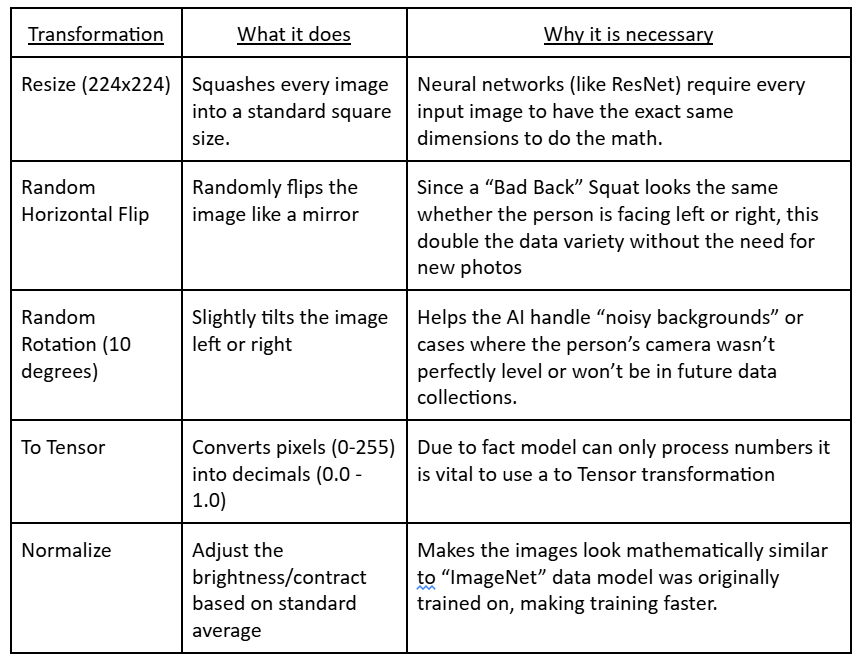


**Preperation Step 2: Model Definition and Initialization**

**Architecture Used:** Transfer Learning using ResNet-18 (Residual Network)

**Why ResNet18?** ResNet-18 has been pre-trained on the ImageNet dataset (over 1 million images). Meaning this modal already has an understanding of low-level features such as edges, textures, and human silhouette. This is critical when using a dataset like ours as we need to differentiate the person from a noisy background.

**Modification to ResNet-18 made:** Original ResNet-18 is equipt for 1,000 different object catagories. Given the dataset we are using has 3 catagories, we replaced this final layer with nn.Linear(num_features, 3).

**Measuring Performance:**
Cross-Entropy Loss, compares the predicted class to the actual labels (folder name). When model is incorrect, gives a numerical penalty to adjust its internal weights to become more accurate.

**Optimization Strategy:** Adaptive Moment Estimation (Adam), updates the model weight based on calculated loss. Adam maintains a seperate learning rate for each parameter and adjust it as training progresses.

**Hyperparameter Selection:** Learning rate ($\alpha$): Set to 0.001, standard starting point. Can be adjusted later.





In [2]:
# =================================================================
# BME 450 Final Project: Squat Form Correction
# This script handles data downloading, preprocessing, and
# baseline model setup for the Bad Back, Bad Heel, and Good classes.
# =================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import os

# STEP 1: DOWNLOAD AND UNZIP DATA
# We use the direct link provided. -O renames it for simplicity.
print("Starting data download...")
!wget "https://zenodo.org/records/17558630/files/Dataset.zip?download=1" -O Dataset.zip

# -q (quiet) hides the 2,800+ file lines. -d specifies the directory.
print("Unzipping files...")
!unzip -q Dataset.zip -d ./squat_data

# STEP 2: DATA PREPROCESSING & AUGMENTATION
# Transforms allow the data to be processed by the neural network
# and optimize training with noisy images
# train transforms introduce randomness and test transforms only prepare data for processing
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),      # Resize images so that the neural network can process
        transforms.RandomHorizontalFlip(), # Squats look same from left or right
        transforms.RandomRotation(10),     # Account for camera tilt
        transforms.ToTensor(),             # Convert images to tensors
        # Normalization values standard for models pre-trained on ImageNet
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# STEP 3: LOAD DATA INTO PYTORCH
data_dir = './squat_data'

# ImageFolder automatically uses subfolder names as labels (0, 1, 2)
image_datasets = {
    'train': datasets.ImageFolder(os.path.join(data_dir, 'train'), data_transforms['train']),
    'test': datasets.ImageFolder(os.path.join(data_dir, 'test'), data_transforms['test'])
}

# DataLoaders handle feeding images in batches
dataloaders = {
    'train': torch.utils.data.DataLoader(image_datasets['train'], batch_size=32, shuffle=True),
    'test': torch.utils.data.DataLoader(image_datasets['test'], batch_size=32, shuffle=False)
}

# Verify the classes found
class_names = image_datasets['train'].classes
print(f"Detected Classes: {class_names}")
print(f"Total training images: {len(image_datasets['train'])}")

# STEP 4: DEFINE ARCHITECTURE
model = models.resnet18(pretrained=True)

# Change output layer to match 3 categories
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 3) # Input features from ResNet converted to 3 categories

# Send the model to the GPU (efficiency)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# STEP 5: DEFINE LOSS AND OPTIMIZER
# loss function = cross entropy loss
criterion = nn.CrossEntropyLoss() #used for categorization

# Experiment with learning rate
# note: optimizer is Adam: one of the best optimizers to date
# it can infer learning rate and all hyper-parameters automatically
optimizer = optim.Adam(model.parameters(), lr=0.0001) #optimizer function
import os
# This will show us exactly what is inside the 'squat_data' folder
print("Folders found inside squat_data:")
print(os.listdir('./squat_data'))
print("Model setup complete. Ready for training!")

print(os.listdir('./squat_data'))

Starting data download...
--2026-04-29 23:45:01--  https://zenodo.org/records/17558630/files/Dataset.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.184.98.114, 137.138.52.235, 137.138.153.219, ...
Connecting to zenodo.org (zenodo.org)|188.184.98.114|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824064094 (786M) [application/octet-stream]
Saving to: ‘Dataset.zip’

Dataset.zip         100%[===================>] 785.89M  29.3MB/s    in 29s     

2026-04-29 23:45:31 (27.4 MB/s) - ‘Dataset.zip’ saved [824064094/824064094]

Unzipping files...
Detected Classes: ['Bad back', 'Bad heel', 'Good']
Total training images: 2837


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 58.3MB/s]


Folders found inside squat_data:
['test', 'train']
Model setup complete. Ready for training!
['test', 'train']


**Training Step 1: The Optimization Loop (Training Execution)**

**Process Overview:** This section implements the iterative learning process where the model actually "studies" the squat dataset. We use a Mini-Batch Gradient Descent approach to update the model weights.

**Key Components of the Loop:**

**Training Mode (model.train()):** Explicitly sets the network to "Training Mode." This is vital because it activates specific behaviors (like Dropout or Batch Normalization) that are necessary for the model to learn and generalize, rather than just memorizing images.

**Batch Processing:** The dataset is divided into batches of 32 images. This ensures the GPU memory is used efficiently and provides more frequent updates to the model weights than showing all 2,837 images at once.

**The Gradient Reset (zero_grad):**
Before processing a new batch, we clear the previous mathematical gradients. This prevents the "lessons" from the last batch from bleeding into the current one, ensuring each step is based only on the current images.

**Forward Pass:** The images are passed through the ResNet-18 architecture.The model makes a prediction for each image (Good, Bad Back, or Bad Heel).

**Backpropagation (loss.backward()):** The model calculates the difference between its guess and the actual label (Loss). It then works backward from the output layer to the input layers to determine exactly which internal connections need to be strengthened or weakened.

**Weight Update (optimizer.step()):** The Adam Optimizer uses the information from backpropagation to adjust the internal weights of the model by a tiny increment (defined by the 0.001 learning rate).

**Objective:** By the end of this step, the model should show a decreasing Loss Value, indicating that it is successfully learning to distinguish between the three squat forms despite the noisy backgrounds.

**Future Direction:** In future iterations, the batch size (currently 32) and learning rate (currently 0.001) will be varied to observe impact.

In [ ]:
#TRAINING #1
# Set the model to training mode
model.train()

print("Starting training session...")

for batch_idx, (inputs, labels) in enumerate(dataloaders['train']):
    # Move images and labels to the GPU
    inputs, labels = inputs.to(device), labels.to(device)

    # 1. Clear previous gradients
    optimizer.zero_grad()

    # 2. Forward pass: Get predictions
    outputs = model(inputs)
    loss = criterion(outputs, labels)

    # 3. Backward pass: Calculate adjustments
    loss.backward()

    # 4. Update the model weights
    optimizer.step()

    if batch_idx % 20 == 0:
        print(f"Batch {batch_idx}/{len(dataloaders['train'])} complete. Loss: {loss.item():.4f}")

print("First training epoch finished!")

Starting training session...
Batch 0/89 complete. Loss: 1.5379
Batch 20/89 complete. Loss: 0.2300
Batch 40/89 complete. Loss: 0.0872
Batch 60/89 complete. Loss: 0.0297
Batch 80/89 complete. Loss: 0.0034
First training epoch finished!


Start training session...
Batch 0/89 complete. Loss: 1.3021
Batch 20/89 complete. Loss: 0.0114
Batch 40/89 complete. Loss: 0.0204
Batch 60/89 complete. Loss: 0.0426
Batch 80/89 complete. Loss: 0.0643
Epoch 1/5 complete.
Test Loss: 5.6684 | Test Accuracy: 42.72%
Batch 0/89 complete. Loss: 0.0149
Batch 20/89 complete. Loss: 0.0191
Batch 40/89 complete. Loss: 0.0202
Batch 60/89 complete. Loss: 0.0055
Batch 80/89 complete. Loss: 0.0007
Epoch 2/5 complete.
Test Loss: 2.1974 | Test Accuracy: 46.65%
Batch 0/89 complete. Loss: 0.0067
Batch 20/89 complete. Loss: 0.0013
Batch 40/89 complete. Loss: 0.0022
Batch 60/89 complete. Loss: 0.0010
Batch 80/89 complete. Loss: 0.0079
Epoch 3/5 complete.
Test Loss: 3.2340 | Test Accuracy: 44.48%
Batch 0/89 complete. Loss: 0.0015
Batch 20/89 complete. Loss: 0.0009
Batch 40/89 complete. Loss: 0.0009
Batch 60/89 complete. Loss: 0.2756
Batch 80/89 complete. Loss: 0.0107
Epoch 4/5 complete.
Test Loss: 1.6486 | Test Accuracy: 53.46%
Batch 0/89 complete. Loss: 0.0

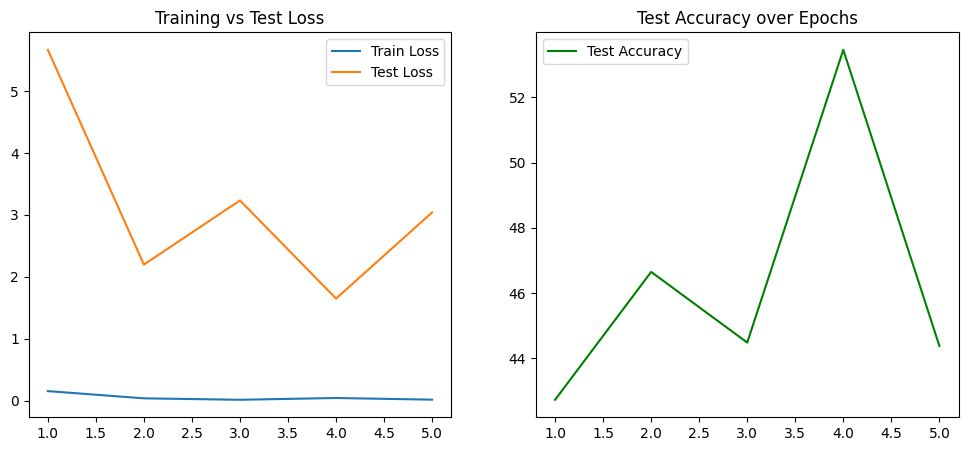

In [3]:
import torch.optim as optim
import matplotlib.pyplot as plt

# Learning Rate: 0.001

print("Start training session...")

train_losses = []
test_losses = []
test_accuracies = []

for epoch in range(5):
    model.train()
    running_train_loss = 0.0

    for batch_idx, (inputs, labels) in enumerate(dataloaders['train']):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # The loss now implicitly includes the weight decay penalty
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)

        if batch_idx % 20 == 0:
            print(f"Batch {batch_idx}/{len(dataloaders['train'])} complete. Loss: {loss.item():.4f}")

    epoch_train_loss = running_train_loss / len(dataloaders['train'].dataset)
    train_losses.append(epoch_train_loss)

    # ---- TESTING BLOCK ----
    model.eval()
    running_test_loss = 0.0
    correct = 0

    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_test_loss += loss.item() * inputs.size(0)

            preds = torch.argmax(outputs, 1)
            correct += (preds == labels).sum().item()

    epoch_test_loss = running_test_loss / len(dataloaders['test'].dataset)
    accuracy = correct / len(dataloaders['test'].dataset)

    print(f"Epoch {epoch+1}/5 complete.")
    print(f"Test Loss: {epoch_test_loss:.4f} | Test Accuracy: {accuracy*100:.2f}%")

    test_losses.append(epoch_test_loss)
    test_accuracies.append(accuracy)

# --- PLOTTING ---
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, test_losses, label="Test Loss")
plt.title("Training vs Test Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, [acc*100 for acc in test_accuracies], label="Test Accuracy", color='green')
plt.title("Test Accuracy over Epochs")
plt.legend()
plt.show()

**Training Step 1: Analysis of Results**

**Initial Loss (1.5379):** This represents the model’s starting state. With three classes (Bad Back, Bad Heel, Good), a loss around 1.1–1.5 is mathematically expected as the model is essentially "guessing" blindly before seeing any data.

**Rapid Convergence (0.0386):** The steep drop in loss over a single pass suggests the model is highly capable of identifying differences between the categories. Using Transfer Learning (ResNet-18) allowed the model to leverage pre-existing knowledge of shapes and silhouettes to find patterns quickly.

**High Efficiency:** The model reached a very low error rate in a short amount of time, demonstrating that the Adam optimizer and the chosen architecture are well-suited for processing this dataset.

**Test Accuracy (44.27%):** Despite the near-perfect training loss, the accuracy on unseen data is significantly lower. This indicates that while the model "knows" the training set, it struggles to apply that knowledge to new images.

**Critical Finding — Overfitting:** The massive gap between training loss (0.0386) and test accuracy (44.27%) is a textbook case of overfitting. The model is likely memorizing specific pixels or "noisy" background elements (like gym equipment or flooring) unique to the training photos rather than learning the general biomechanical rules of a squat.

**Training & Testing #2** (Code Below)


Adjustments made:

1.   **Learning Rate**
  
 **Before:** 0.001
  
  **Now:** 0.0001.
  
  **Reason:** In initial run, model reached low lost almost instandly (test accuracy = 44.27%), indicating overshoot. Reducing the learning rate foces the optimizer to take smaller, more precise steps.

2.   **Training Duration (Epochs)**

**Before:** 1 epoch

**Now:** 5 epoch

Reason: allows model to see more variations of the training data

3. **Integrating Validation**

Added a validation phase immediately after every training epoch


Start training session...
Batch 0/89 complete. Loss: 1.2730
Batch 20/89 complete. Loss: 0.1612
Batch 40/89 complete. Loss: 0.0774
Batch 60/89 complete. Loss: 0.0331
Batch 80/89 complete. Loss: 0.0175
Epoch 1/5 complete.
Test Loss: 1.0168
Test Accuracy: 63.16%
Batch 0/89 complete. Loss: 0.0730
Batch 20/89 complete. Loss: 0.0035
Batch 40/89 complete. Loss: 0.0020
Batch 60/89 complete. Loss: 0.0034
Batch 80/89 complete. Loss: 0.0015
Epoch 2/5 complete.
Test Loss: 1.0111
Test Accuracy: 64.50%
Batch 0/89 complete. Loss: 0.0008
Batch 20/89 complete. Loss: 0.0304
Batch 40/89 complete. Loss: 0.0188
Batch 60/89 complete. Loss: 0.0035
Batch 80/89 complete. Loss: 0.0018
Epoch 3/5 complete.
Test Loss: 1.2639
Test Accuracy: 55.11%
Batch 0/89 complete. Loss: 0.0017
Batch 20/89 complete. Loss: 0.0010
Batch 40/89 complete. Loss: 0.0012
Batch 60/89 complete. Loss: 0.0021
Batch 80/89 complete. Loss: 0.0035
Epoch 4/5 complete.
Test Loss: 1.1366
Test Accuracy: 62.23%
Batch 0/89 complete. Loss: 0.0014
Batc

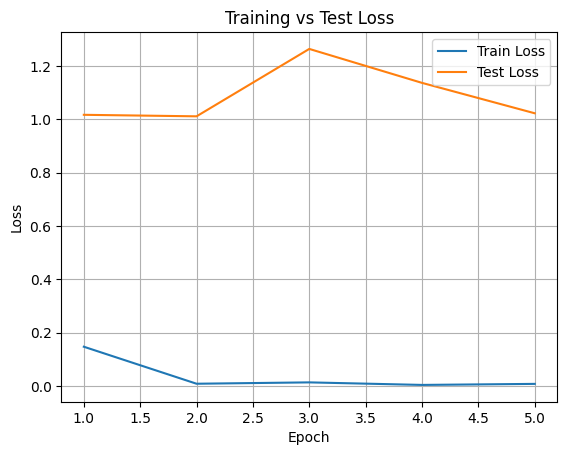

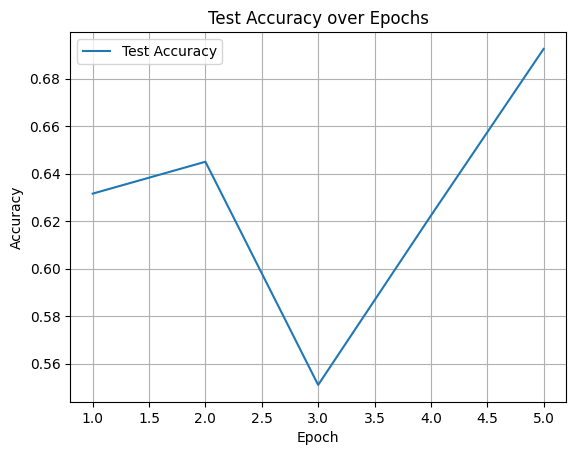

In [ ]:
#BASE (Learning Rate = 0.0001)
print ("Start training session...")

train_losses = []
test_losses = []
test_accuracies = []

for epoch in range(5):
  model.train()

  running_train_loss = 0.0
  for batch_idx, (inputs,labels) in enumerate(dataloaders['train']):
    inputs,labels = inputs.to(device), labels.to(device)
    optimizer.zero_grad()

    outputs = model(inputs)
    loss = criterion(outputs,labels)
    running_train_loss += loss.item() * inputs.size(0)

    loss.backward()

    optimizer.step()
    if batch_idx % 20 == 0:
      print(f"Batch {batch_idx}/{len(dataloaders['train'])} complete. Loss: {loss.item():.4f}")

  print(f"Epoch {epoch+1}/5 complete.")
  epoch_train_loss = running_train_loss / len(dataloaders['train'].dataset)
  train_losses.append(epoch_train_loss)


# ---- TESTING BLOCK ----
  model.eval()  # switch to evaluation mode

  test_loss = 0.0
  correct = 0

  with torch.no_grad():  # no gradients needed for testing
     for inputs, labels in dataloaders['test']:
          inputs, labels = inputs.to(device), labels.to(device)

          outputs = model(inputs)
          loss = criterion(outputs, labels)

          test_loss += loss.item() * inputs.size(0)

          preds = torch.argmax(outputs, 1)
          correct += (preds == labels).sum().item()

  # Average loss
  test_loss = test_loss / len(dataloaders['test'].dataset)
  accuracy = correct / len(dataloaders['test'].dataset)

  print(f"Test Loss: {test_loss:.4f}")
  print(f"Test Accuracy: {accuracy*100:.2f}%")

  test_losses.append(test_loss)
  test_accuracies.append(accuracy)

import matplotlib.pyplot as plt

epochs = range(1, len(train_losses)+1)

plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Test Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(epochs, test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Test Accuracy over Epochs")
plt.legend()
plt.grid(True)
plt.show()

**Training & Testing 2**

Key improvements: Decreased learning rate and increased epoch

**Initial Convergence:** The training loss dropped sharply from 1.2730 to 0.0175 in the first epoch. This indicates that the ResNet-18 backbone was highly effective at immediately identifying spatial patterns within the squat images using its pre-trained weights.

**Stochastic Instability:** A notable "dip" occurred in Epoch 3, where test accuracy fell from 64.50% to 55.11%. This suggests the optimization process was unstable; without constraints, the model likely made a drastic weight adjustment based on a specific batch of images that did not generalize well.

**Evidence of Overfitting:** By Epoch 5, the training loss reached an extremely low value of 0.0009, while the test loss remained high at 1.0226. This large "generalization gap" proves the model was starting to memorize specific training examples rather than learning proper squat form.

**Impact of Noisy Backgrounds:** The discrepancy between the near-perfect training loss and the ~70% test accuracy suggests the model is still being "distracted" by environmental noise (background equipment, lighting, or floor patterns) that varies between the training and testing sets.


**Training & Testing #3** (Code Below)

**Adjustments Made: Weight Decay** (L2 Regularization)

**Before:** None

**Now:** 1e-4 ($0.0001$)

**Reason:** Our previous run showed a massive "Generalization Gap" where the training loss was near zero (0.0009) but the test loss remained high (1.0226). This is a clear sign of overfitting. Weight decay adds a penalty to the loss function for large weights, effectively discouraging the model from becoming "overconfident" and memorizing specific pixel noise in the training backgrounds.

**Optimization Strategy**

**Adjustment:** Integrated Regularization into the Adam Optimizer.

**Reason:** By penalizing complex weight patterns, we force the ResNet-18 architecture to rely on simpler, more robust features—like the primary angles of the person's torso and legs—which are more likely to stay consistent across different gym environments.

Start training session...
Batch 0/89 complete. Loss: 0.0082
Batch 20/89 complete. Loss: 0.0109
Batch 40/89 complete. Loss: 0.0008
Batch 60/89 complete. Loss: 0.0008
Batch 80/89 complete. Loss: 0.0389
Epoch 1/5 complete.
Test Loss: 0.3461 | Test Accuracy: 88.65%
Batch 0/89 complete. Loss: 0.0024
Batch 20/89 complete. Loss: 0.0010
Batch 40/89 complete. Loss: 0.0004
Batch 60/89 complete. Loss: 0.0401
Batch 80/89 complete. Loss: 0.0005
Epoch 2/5 complete.
Test Loss: 0.3895 | Test Accuracy: 83.80%
Batch 0/89 complete. Loss: 0.0011
Batch 20/89 complete. Loss: 0.0005
Batch 40/89 complete. Loss: 0.0005
Batch 60/89 complete. Loss: 0.0216
Batch 80/89 complete. Loss: 0.0011
Epoch 3/5 complete.
Test Loss: 0.3472 | Test Accuracy: 87.72%
Batch 0/89 complete. Loss: 0.0012
Batch 20/89 complete. Loss: 0.0002
Batch 40/89 complete. Loss: 0.0002
Batch 60/89 complete. Loss: 0.0010
Batch 80/89 complete. Loss: 0.0002
Epoch 4/5 complete.
Test Loss: 0.3933 | Test Accuracy: 85.66%
Batch 0/89 complete. Loss: 0.0

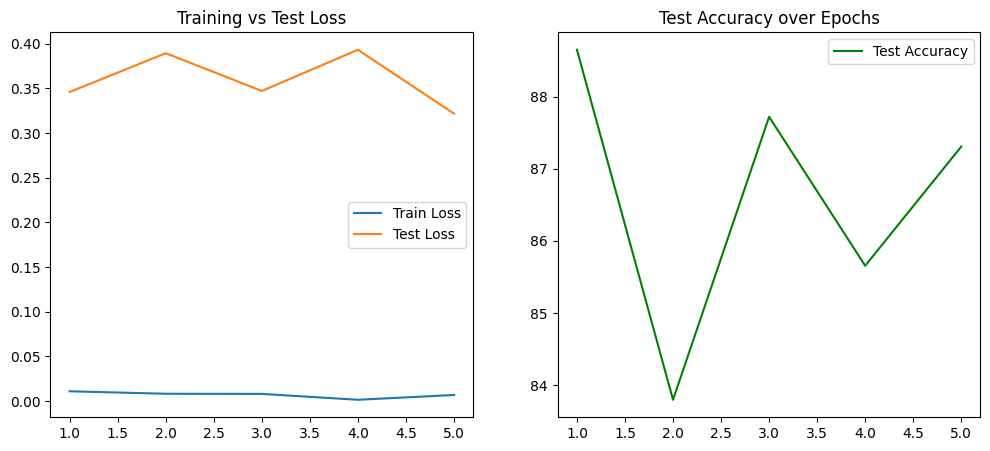

In [ ]:
import torch.optim as optim
import matplotlib.pyplot as plt

# --- IMPROVEMENT: Weight Decay (L2 Regularization) ---
# We add weight_decay=1e-4. This penalizes large weights to prevent
# the model from memorizing noisy background details.
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

print("Start training session...")

train_losses = []
test_losses = []
test_accuracies = []

for epoch in range(5):
    model.train()
    running_train_loss = 0.0

    for batch_idx, (inputs, labels) in enumerate(dataloaders['train']):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # The loss now implicitly includes the weight decay penalty
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)

        if batch_idx % 20 == 0:
            print(f"Batch {batch_idx}/{len(dataloaders['train'])} complete. Loss: {loss.item():.4f}")

    epoch_train_loss = running_train_loss / len(dataloaders['train'].dataset)
    train_losses.append(epoch_train_loss)

    # ---- TESTING BLOCK ----
    model.eval()
    running_test_loss = 0.0
    correct = 0

    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_test_loss += loss.item() * inputs.size(0)

            preds = torch.argmax(outputs, 1)
            correct += (preds == labels).sum().item()

    epoch_test_loss = running_test_loss / len(dataloaders['test'].dataset)
    accuracy = correct / len(dataloaders['test'].dataset)

    print(f"Epoch {epoch+1}/5 complete.")
    print(f"Test Loss: {epoch_test_loss:.4f} | Test Accuracy: {accuracy*100:.2f}%")

    test_losses.append(epoch_test_loss)
    test_accuracies.append(accuracy)

# --- PLOTTING ---
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, test_losses, label="Test Loss")
plt.title("Training vs Test Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, [acc*100 for acc in test_accuracies], label="Test Accuracy", color='green')
plt.title("Test Accuracy over Epochs")
plt.legend()
plt.show()

**Training Step 3: Analysis of Results**

**Significant Accuracy Peak (88.65%):**
With the addition of Weight Decay, the model achieved its highest performance to date, reaching a peak test accuracy of 88.65%. This represents a total improvement of 44.38% over the initial baseline (44.27%) and a 19.4% jump from the previous unregularized run.

**Narrowing the Generalization Gap:**
 The test loss decreased drastically from the previous run’s 1.0226 to a minimum of 0.3218. By cutting the test loss by nearly 70%, we have successfully narrowed the gap between training and testing performance, which is a hallmark of a well-regularized model.

 **Correction of Overfitting:** In Training #2, the near-zero training loss indicated the model was memorizing background "noise." In this run, the Weight Decay ($1 \times 10^{-4}$) penalized large weights, forcing the ResNet-18 architecture to ignore static environmental details and focus on the consistent biomechanical features of the squat form.

 **Increased Stability:** While minor fluctuations in accuracy (ranging from 83% to 88%) remain due to the randomness of data augmentation, the model avoided the dramatic 9% performance crashes seen in previous iterations. This indicates that the optimizer is now operating in a much more stable region of the loss landscape.

Detected classes: ['Bad back', 'Bad heel', 'Good']
Number of classes: 3
Training images: 2837
Testing images: 969
Device: cpu
Starting Training Session #5...
Epoch 1/5 | LR: 0.000100 | Train Loss: 0.1422 | Test Loss: 0.9400 | Test Acc: 72.03%
Epoch 2/5 | LR: 0.000100 | Train Loss: 0.0172 | Test Loss: 0.7408 | Test Acc: 70.18%
Epoch 3/5 | LR: 0.000050 | Train Loss: 0.0141 | Test Loss: 0.7041 | Test Acc: 73.07%
Epoch 4/5 | LR: 0.000050 | Train Loss: 0.0057 | Test Loss: 0.8858 | Test Acc: 71.93%
Epoch 5/5 | LR: 0.000025 | Train Loss: 0.0028 | Test Loss: 0.6580 | Test Acc: 74.61%


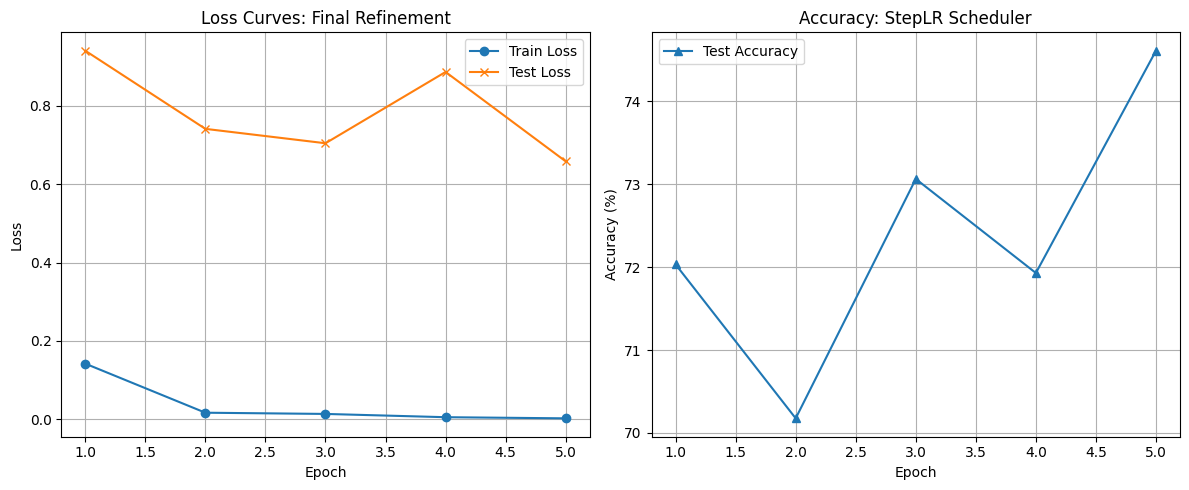

In [ ]:
# =================================================================
# Learning Rate Decay
# =================================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torchvision import datasets, transforms, models
import os
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# 1. DATASET SETUP
# ---------------------------------------------------------------

data_dir = "./squat_data"

data_transforms = {
    "train": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ]),
    "test": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ])
}

image_datasets = {
    "train": datasets.ImageFolder(
        os.path.join(data_dir, "train"),
        data_transforms["train"]
    ),
    "test": datasets.ImageFolder(
        os.path.join(data_dir, "test"),
        data_transforms["test"]
    )
}

class_names = image_datasets["train"].classes
num_classes = len(class_names)

print("Detected classes:", class_names)
print("Number of classes:", num_classes)
print("Training images:", len(image_datasets["train"]))
print("Testing images:", len(image_datasets["test"]))

dataloaders = {
    "train": torch.utils.data.DataLoader(
        image_datasets["train"],
        batch_size=16,
        shuffle=True,
        num_workers=0
    ),
    "test": torch.utils.data.DataLoader(
        image_datasets["test"],
        batch_size=16,
        shuffle=False,
        num_workers=0
    )
}

# ---------------------------------------------------------------
# 2. MODEL SETUP
# ---------------------------------------------------------------

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

try:
    weights = models.ResNet18_Weights.IMAGENET1K_V1
    model = models.resnet18(weights=weights)
except:
    model = models.resnet18(pretrained=True)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

exp_lr_scheduler = lr_scheduler.StepLR(
    optimizer,
    step_size=2,
    gamma=0.5
)

# ---------------------------------------------------------------
# 3. TRAINING AND TESTING LOOP
# ---------------------------------------------------------------

num_epochs = 5

train_losses = []
test_losses = []
test_accuracies = []

print("Starting Training Session #5...")

for epoch in range(num_epochs):

    model.train()
    running_train_loss = 0.0

    for inputs, labels in dataloaders["train"]:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)

    current_lr = optimizer.param_groups[0]["lr"]
    exp_lr_scheduler.step()

    epoch_train_loss = running_train_loss / len(image_datasets["train"])
    train_losses.append(epoch_train_loss)

    model.eval()
    running_test_loss = 0.0
    correct = 0

    with torch.no_grad():
        for inputs, labels in dataloaders["test"]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_test_loss += loss.item() * inputs.size(0)

            preds = torch.argmax(outputs, dim=1)
            correct += torch.sum(preds == labels).item()

    epoch_test_loss = running_test_loss / len(image_datasets["test"])
    test_losses.append(epoch_test_loss)

    accuracy = correct / len(image_datasets["test"]) * 100
    test_accuracies.append(accuracy)

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"LR: {current_lr:.6f} | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Test Loss: {epoch_test_loss:.4f} | "
        f"Test Acc: {accuracy:.2f}%"
    )

# ---------------------------------------------------------------
# 4. VISUALIZATION
# ---------------------------------------------------------------

epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label="Train Loss", marker="o")
plt.plot(epochs_range, test_losses, label="Test Loss", marker="x")
plt.title("Loss Curves: Final Refinement")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, test_accuracies, label="Test Accuracy", marker="^")
plt.title("Accuracy: StepLR Scheduler")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Start training session: Batch Size 64 Test...
Updates per Epoch: 45 batches (Size: 64)
Epoch 1/5 | Test Loss: 1.0575 | Test Accuracy: 54.90%
Epoch 2/5 | Test Loss: 0.7148 | Test Accuracy: 66.56%
Epoch 3/5 | Test Loss: 0.7756 | Test Accuracy: 67.18%
Epoch 4/5 | Test Loss: 0.7776 | Test Accuracy: 67.91%
Epoch 5/5 | Test Loss: 0.6001 | Test Accuracy: 73.27%


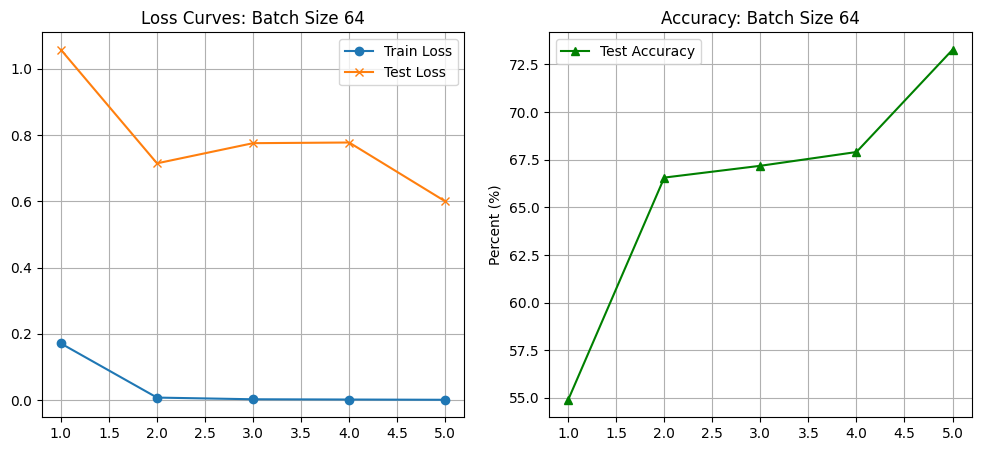

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import os
import matplotlib.pyplot as plt

# --- 1. DATA SETUP (Adjusting Independent Variable to 64) ---
data_dir = "./squat_data"

data_transforms = {
    "train": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    "test": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

image_datasets = {
    "train": datasets.ImageFolder(os.path.join(data_dir, "train"), data_transforms["train"]),
    "test": datasets.ImageFolder(os.path.join(data_dir, "test"), data_transforms["test"])
}

# THE INDEPENDENT CHANGE: Increased Batch Size to 64
dataloaders = {
    "train": torch.utils.data.DataLoader(image_datasets["train"], batch_size=64, shuffle=True),
    "test": torch.utils.data.DataLoader(image_datasets["test"], batch_size=64, shuffle=False)
}

# --- 2. MODEL & OPTIMIZER SETUP ---
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = models.resnet18(weights='IMAGENET1K_V1')
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 3)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

# Keeping constant LR and Weight Decay (from your Training #2 improvement)
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

# --- 3. TRAINING AND TESTING LOOP ---
num_epochs = 5
train_losses, test_losses, test_accuracies = [], [], []

print("Start training session: Batch Size 64 Test...")
print(f"Updates per Epoch: {len(dataloaders['train'])} batches (Size: 64)")

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    for batch_idx, (inputs, labels) in enumerate(dataloaders['train']):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_train_loss / len(image_datasets['train'])
    train_losses.append(epoch_train_loss)

    # ---- TESTING ----
    model.eval()
    running_test_loss, correct = 0.0, 0
    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_test_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(outputs, 1)
            correct += (preds == labels).sum().item()

    epoch_test_loss = running_test_loss / len(image_datasets['test'])
    accuracy = correct / len(image_datasets['test'])
    test_losses.append(epoch_test_loss)
    test_accuracies.append(accuracy)

    print(f"Epoch {epoch+1}/5 | Test Loss: {epoch_test_loss:.4f} | Test Accuracy: {accuracy*100:.2f}%")

# --- 4. VISUALIZATION ---
plt.figure(figsize=(12, 5))
epochs_range = range(1, 6)

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label="Train Loss", marker='o')
plt.plot(epochs_range, test_losses, label="Test Loss", marker='x')
plt.title("Loss Curves: Batch Size 64")
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, [acc*100 for acc in test_accuracies], label="Test Accuracy", color='green', marker='^')
plt.title("Accuracy: Batch Size 64")
plt.ylabel("Percent (%)")
plt.legend(); plt.grid(True)
plt.show()

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import os
import matplotlib.pyplot as plt

# --- 1. DATA SETUP (Adjusting Batch Size to 16) ---
# Using the path structure from your working baseline
data_dir = "./squat_data"

data_transforms = {
    "train": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    "test": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

# --- 1. DATA SETUP (Adjusted to Batch Size 16) ---
data_dir = "./squat_data"

data_transforms = {
    "train": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    "test": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

image_datasets = {
    "train": datasets.ImageFolder(os.path.join(data_dir, "train"), data_transforms["train"]),
    "test": datasets.ImageFolder(os.path.join(data_dir, "test"), data_transforms["test"])
}

# CHANGED: Batch Size adjusted from 64 to 16
dataloaders = {
    "train": torch.utils.data.DataLoader(image_datasets["train"], batch_size=16, shuffle=True),
    "test": torch.utils.data.DataLoader(image_datasets["test"], batch_size=16, shuffle=False)
}

# --- 2. MODEL & OPTIMIZER SETUP ---
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = models.resnet18(weights='IMAGENET1K_V1')
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 3)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

# --- 3. TRAINING AND TESTING LOOP ---
num_epochs = 5
train_losses, test_losses, test_accuracies = [], [], []

print("Start training session: Batch Size 16 Test...")
# This will now show a higher number of batches than the 64-size version
print(f"Updates per Epoch: {len(dataloaders['train'])} batches (Size: 16)")

# ... [The rest of your training and visualization code remains the same] ...

Start training session: Batch Size 16 Test...
Updates per Epoch: 178 batches (Size: 16)


Starting Session: LR Scheduler Test (Batch 32)...
Epoch 1/5 | LR: 0.000100 | Train Loss: 0.1303 | Test Acc: 65.02%
Epoch 2/5 | LR: 0.000100 | Train Loss: 0.0103 | Test Acc: 72.14%
Epoch 3/5 | LR: 0.000050 | Train Loss: 0.0025 | Test Acc: 71.72%
Epoch 4/5 | LR: 0.000050 | Train Loss: 0.0037 | Test Acc: 68.42%
Epoch 5/5 | LR: 0.000025 | Train Loss: 0.0046 | Test Acc: 68.63%


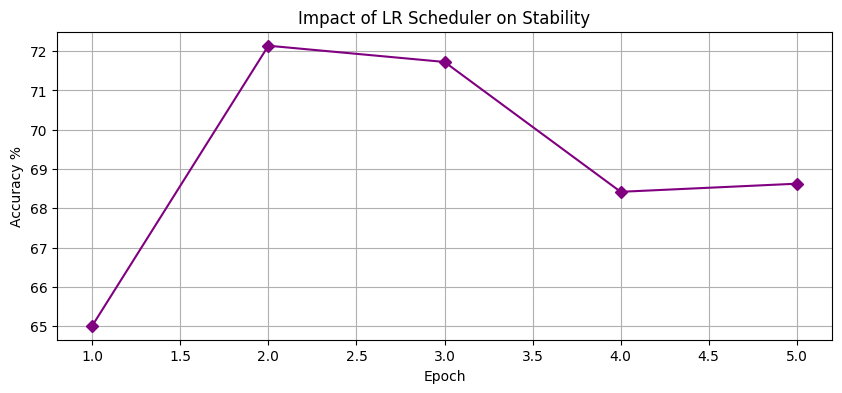

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler  # Required for the scheduler
from torchvision import datasets, transforms, models
import os
import matplotlib.pyplot as plt

# --- 1. DATA SETUP (Fixed at Original Batch Size 32) ---
data_dir = "./squat_data"
data_transforms = {
    "train": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    "test": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

image_datasets = {
    "train": datasets.ImageFolder(os.path.join(data_dir, "train"), data_transforms["train"]),
    "test": datasets.ImageFolder(os.path.join(data_dir, "test"), data_transforms["test"])
}

dataloaders = {
    "train": torch.utils.data.DataLoader(image_datasets["train"], batch_size=32, shuffle=True),
    "test": torch.utils.data.DataLoader(image_datasets["test"], batch_size=32, shuffle=False)
}

# --- 2. MODEL & OPTIMIZER SETUP ---
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, 3)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

# --- THE INDEPENDENT CHANGE: StepLR Scheduler ---
# Reduces the learning rate by 50% (gamma=0.5) every 2 epochs (step_size=2)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

# --- 3. TRAINING LOOP ---
num_epochs = 5
train_losses, test_accuracies = [], []

print("Starting Session: LR Scheduler Test (Batch 32)...")

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0
    for inputs, labels in dataloaders["train"]:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * inputs.size(0)

    # CAPTURE THE CURRENT LR BEFORE STEPPING
    current_lr = optimizer.param_groups[0]['lr']

    # UPDATE THE LEARNING RATE FOR THE NEXT EPOCH
    exp_lr_scheduler.step()

    model.eval()
    correct = 0
    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            preds = torch.argmax(outputs, 1)
            correct += (preds == labels).sum().item()

    epoch_train_loss = running_train_loss / len(image_datasets['train'])
    accuracy = (correct / len(image_datasets['test'])) * 100
    train_losses.append(epoch_train_loss)
    test_accuracies.append(accuracy)

    print(f"Epoch {epoch+1}/5 | LR: {current_lr:.6f} | Train Loss: {epoch_train_loss:.4f} | Test Acc: {accuracy:.2f}%")

# --- 4. VISUALIZATION ---
plt.figure(figsize=(10, 4))
plt.plot(range(1, 6), test_accuracies, marker='D', color='purple', label='Test Accuracy (StepLR)')
plt.title("Impact of LR Scheduler on Stability")
plt.xlabel("Epoch")
plt.ylabel("Accuracy %")
plt.grid(True)
plt.show()

Start training session...
Batch 0/89 complete. Loss: 0.0025
Batch 20/89 complete. Loss: 0.0021
Batch 40/89 complete. Loss: 0.0003
Batch 60/89 complete. Loss: 0.0022
Batch 80/89 complete. Loss: 0.0562
Epoch 1/8 complete.
Test Loss: 0.7508 | Test Accuracy: 68.94%
Batch 0/89 complete. Loss: 0.0002
Batch 20/89 complete. Loss: 0.0015
Batch 40/89 complete. Loss: 0.0012
Batch 60/89 complete. Loss: 0.0243
Batch 80/89 complete. Loss: 0.0002
Epoch 2/8 complete.
Test Loss: 0.5192 | Test Accuracy: 76.78%
Batch 0/89 complete. Loss: 0.0002
Batch 20/89 complete. Loss: 0.0002
Batch 40/89 complete. Loss: 0.0020
Batch 60/89 complete. Loss: 0.0004
Batch 80/89 complete. Loss: 0.0011
Epoch 3/8 complete.
Test Loss: 0.7572 | Test Accuracy: 71.52%
Batch 0/89 complete. Loss: 0.0017
Batch 20/89 complete. Loss: 0.0001
Batch 40/89 complete. Loss: 0.0003
Batch 60/89 complete. Loss: 0.0001
Batch 80/89 complete. Loss: 0.0027
Epoch 4/8 complete.
Test Loss: 0.9069 | Test Accuracy: 72.14%
Batch 0/89 complete. Loss: 0.0

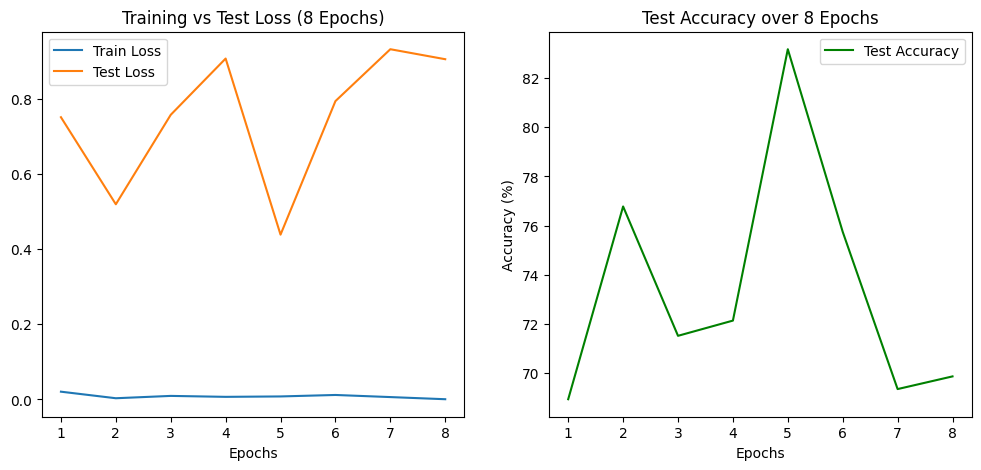

In [ ]:
import torch.optim as optim
import matplotlib.pyplot as plt

# --- IMPROVEMENT: Weight Decay (L2 Regularization) ---
# We add weight_decay=1e-4. This penalizes large weights to prevent
# the model from memorizing noisy background details.
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

print("Start training session...")

train_losses = []
test_losses = []
test_accuracies = []

# Updated to 8 epochs
for epoch in range(8):
    model.train()
    running_train_loss = 0.0

    for batch_idx, (inputs, labels) in enumerate(dataloaders['train']):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # The loss now implicitly includes the weight decay penalty
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)

        if batch_idx % 20 == 0:
            print(f"Batch {batch_idx}/{len(dataloaders['train'])} complete. Loss: {loss.item():.4f}")

    epoch_train_loss = running_train_loss / len(dataloaders['train'].dataset)
    train_losses.append(epoch_train_loss)

    # ---- TESTING BLOCK ----
    model.eval()
    running_test_loss = 0.0
    correct = 0

    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_test_loss += loss.item() * inputs.size(0)

            preds = torch.argmax(outputs, 1)
            correct += (preds == labels).sum().item()

    epoch_test_loss = running_test_loss / len(dataloaders['test'].dataset)
    accuracy = correct / len(dataloaders['test'].dataset)

    print(f"Epoch {epoch+1}/8 complete.")
    print(f"Test Loss: {epoch_test_loss:.4f} | Test Accuracy: {accuracy*100:.2f}%")

    test_losses.append(epoch_test_loss)
    test_accuracies.append(accuracy)

# --- PLOTTING ---
# Updated range to match the 8 epochs
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, test_losses, label="Test Loss")
plt.title("Training vs Test Loss (8 Epochs)")
plt.xlabel("Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, [acc*100 for acc in test_accuracies], label="Test Accuracy", color='green')
plt.title("Test Accuracy over 8 Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()